 ###Data Understanding + Data Quality Inspection.


In [ ]:
# 1. Import Required Libraries

import pandas as pd
#  Import Visualization Libraries

import matplotlib.pyplot as plt
import seaborn as sns

In [25]:
# 2. Load the Dataset

df = pd.read_csv("../datasets/raw/telco_churn.csv")

In [26]:
# 3. Check Dataset Dimensions

print("Dataset Shape:", df.shape)

Dataset Shape: (7043, 21)


In [27]:
# 4. Preview the First Five Records

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [28]:
# 5. Inspect Dataset Structure and Data Types

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [29]:
# 6. Check Missing Values

df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [30]:
# 7. Analyze Target Variable Distribution

df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [31]:
# 8. Analyze Target Variable Distribution in Percentage

df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

In [32]:
# 9. Inspect TotalCharges Values

df["TotalCharges"].value_counts().head(15)

TotalCharges
20.2     11
         11
19.75     9
19.65     8
19.9      8
20.05     8
19.55     7
45.3      7
19.45     6
20.25     6
20.15     6
20.45     5
20.3      5
19.4      4
75.3      4
Name: count, dtype: int64

In [33]:
# 10. Checking Blank or Whitespace Values in TotalCharges

blank_total_charges = df["TotalCharges"].str.strip().eq("").sum()

print("Blank values in TotalCharges:", blank_total_charges)

Blank values in TotalCharges: 11


In [34]:
# 11. Check Duplicate Records

print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [35]:
# 12. Check Customer ID Uniqueness

print("Unique Customer IDs:", df["customerID"].nunique())
print("Total Records:", len(df))

Unique Customer IDs: 7043
Total Records: 7043


In [36]:
# 13. Inspect Records with Blank TotalCharges

blank_records = df[df["TotalCharges"].str.strip() == ""]

blank_records[
    ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]
]

,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


In [37]:
# 14. Convert TotalCharges to Numeric

df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [38]:
# 15. Handle Missing TotalCharges for New Customers

df["TotalCharges"] = df["TotalCharges"].fillna(0)

In [39]:
# 16. Verify TotalCharges Cleaning

print("Data type:", df["TotalCharges"].dtype)
print("Missing values:", df["TotalCharges"].isnull().sum())

Data type: float64
Missing values: 0


In [40]:
# 17. Identify Numerical and Categorical Features

numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_columns = df.select_dtypes(include=["object"]).columns.tolist()

print("Numerical Columns:")
print(numerical_columns)

print("\nCategorical Columns:")
print(categorical_columns)

Numerical Columns:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical Columns:
['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


In [41]:
# 18. Inspect Unique Values in Categorical Features

for column in categorical_columns:
    print(f"\n{column}:")
    print(df[column].value_counts())


customerID:
customerID
7590-VHVEG    1
5575-GNVDE    1
3668-QPYBK    1
7795-CFOCW    1
9237-HQITU    1
             ..
6840-RESVB    1
2234-XADUH    1
4801-JZAZL    1
8361-LTMKD    1
3186-AJIEK    1
Name: count, Length: 7043, dtype: int64

gender:
gender
Male      3555
Female    3488
Name: count, dtype: int64

Partner:
Partner
No     3641
Yes    3402
Name: count, dtype: int64

Dependents:
Dependents
No     4933
Yes    2110
Name: count, dtype: int64

PhoneService:
PhoneService
Yes    6361
No      682
Name: count, dtype: int64

MultipleLines:
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

InternetService:
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

OnlineSecurity:
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64

OnlineBackup:
OnlineBackup
No                     3088
Yes                

In [42]:
# 19. Inspect Unique Values of Predictive Categorical Features

categorical_features = [
    col for col in categorical_columns
    if col not in ["customerID", "Churn"]
]

for column in categorical_features:
    print(f"\n{column}:")
    print(df[column].value_counts())


gender:


gender
Male      3555
Female    3488
Name: count, dtype: int64

Partner:
Partner
No     3641
Yes    3402
Name: count, dtype: int64

Dependents:
Dependents
No     4933
Yes    2110
Name: count, dtype: int64

PhoneService:
PhoneService
Yes    6361
No      682
Name: count, dtype: int64

MultipleLines:
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

InternetService:
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

OnlineSecurity:
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64

OnlineBackup:
OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64

DeviceProtection:
DeviceProtection
No                     3095
Yes                    2422
No internet service    1526
Name: count, dtype: int64

TechSupport:
TechSupport
No           

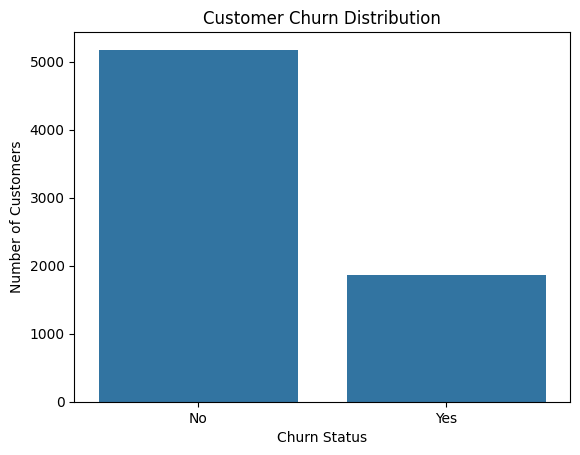

In [43]:
# 21. Visualize Churn Distribution

sns.countplot(data=df, x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn Status")
plt.ylabel("Number of Customers")
plt.show()

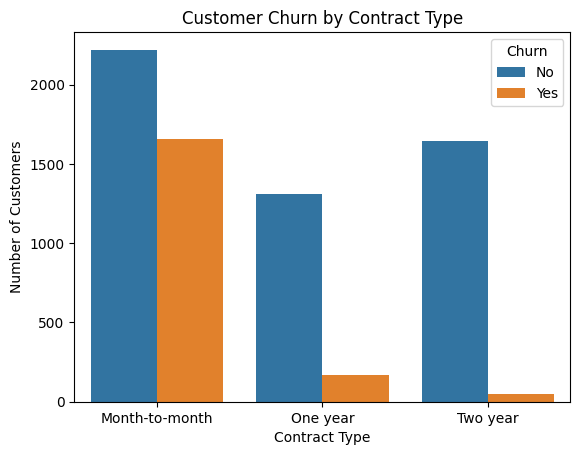

In [46]:
# 22. Analyze Churn by Contract Type

sns.countplot(data=df, x="Contract", hue="Churn")

plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.show()

Contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: Churn, dtype: float64


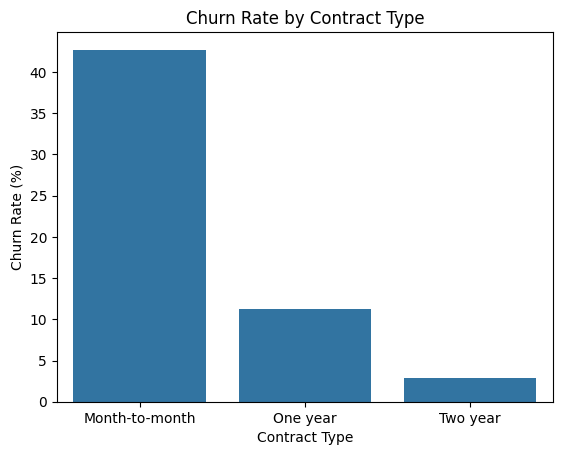

In [47]:
# 23. Calculate Churn Rate by Contract Type

contract_churn_rate = (
    df.groupby("Contract")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .sort_values(ascending=False)
)

print(contract_churn_rate)

sns.barplot(
    x=contract_churn_rate.index,
    y=contract_churn_rate.values
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.show()

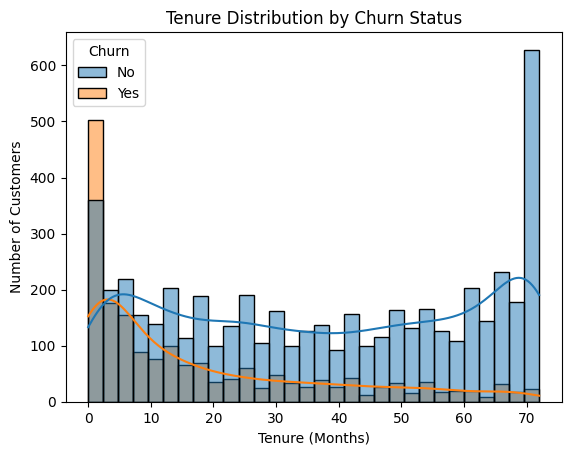

In [48]:
# 25. Analyze Tenure Distribution by Churn Status

sns.histplot(
    data=df,
    x="tenure",
    hue="Churn",
    bins=30,
    kde=True,
    multiple="layer"
)

plt.title("Tenure Distribution by Churn Status")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")
plt.show()

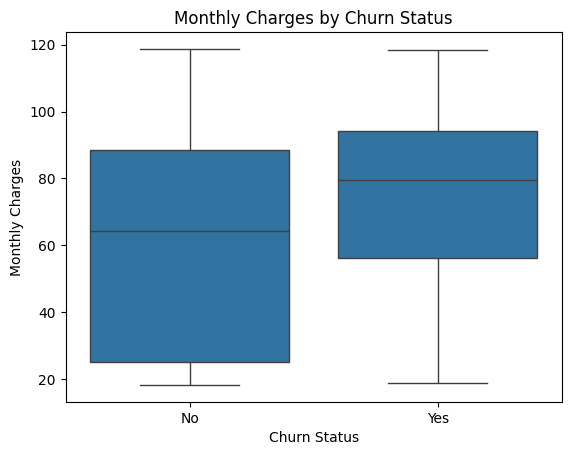

In [49]:
# 26. Analyze Monthly Charges by Churn Status

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges by Churn Status")
plt.xlabel("Churn Status")
plt.ylabel("Monthly Charges")
plt.show()

InternetService
Fiber optic    41.892765
DSL            18.959108
No              7.404980
Name: Churn, dtype: float64


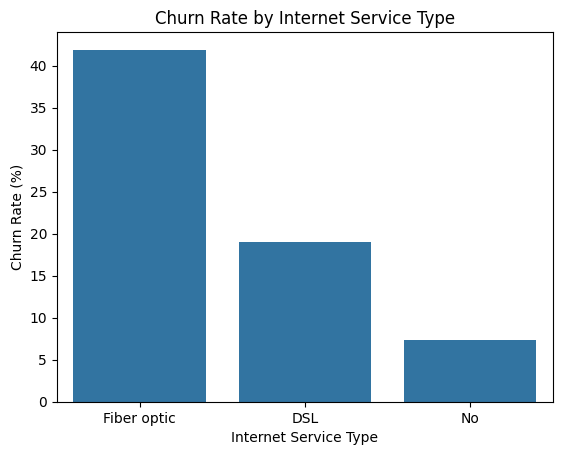

In [50]:
# 27. Calculate Churn Rate by Internet Service Type

internet_churn_rate = (
    df.groupby("InternetService")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .sort_values(ascending=False)
)

print(internet_churn_rate)

# 28. Visualize Churn Rate by Internet Service Type

sns.barplot(
    x=internet_churn_rate.index,
    y=internet_churn_rate.values
)

plt.title("Churn Rate by Internet Service Type")
plt.xlabel("Internet Service Type")
plt.ylabel("Churn Rate (%)")
plt.show()

TechSupport
No                     41.635474
Yes                    15.166341
No internet service     7.404980
Name: Churn, dtype: float64


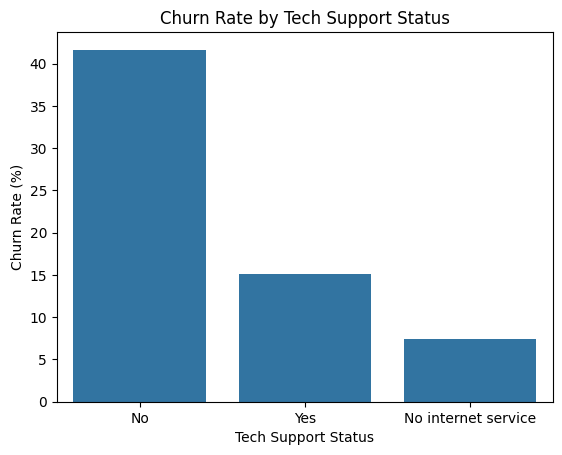

In [52]:
# 29. Calculate Churn Rate by Tech Support Status

tech_support_churn_rate = (
    df.groupby("TechSupport")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .sort_values(ascending=False)
)

print(tech_support_churn_rate)

# 30. Visualize Churn Rate by Tech Support Status

sns.barplot(
    x=tech_support_churn_rate.index,
    y=tech_support_churn_rate.values
)

plt.title("Churn Rate by Tech Support Status")
plt.xlabel("Tech Support Status")
plt.ylabel("Churn Rate (%)")
plt.show()

PaymentMethod
Electronic check             45.285412
Mailed check                 19.106700
Bank transfer (automatic)    16.709845
Credit card (automatic)      15.243101
Name: Churn, dtype: float64


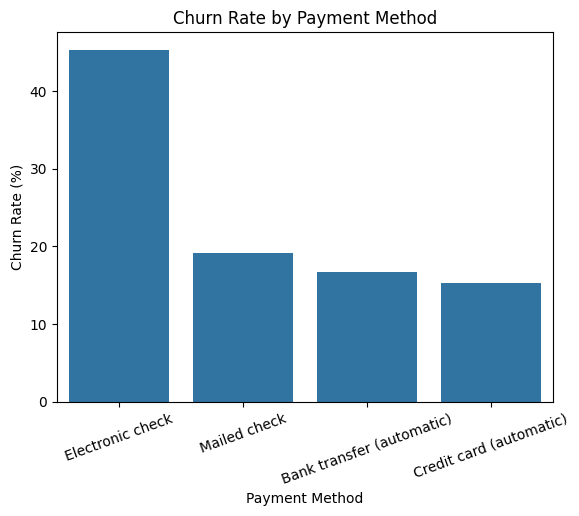

In [53]:
# 31. Calculate Churn Rate by Payment Method

payment_churn_rate = (
    df.groupby("PaymentMethod")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .sort_values(ascending=False)
)

print(payment_churn_rate)

# 32. Visualize Churn Rate by Payment Method

sns.barplot(
    x=payment_churn_rate.index,
    y=payment_churn_rate.values
)

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=20)
plt.show()

In [54]:
# 33. Summarize Churn Rates Across Selected Categorical Features

summary_features = [
    "gender",
    "SeniorCitizen",
    "Partner",
    "Dependents",
    "PaperlessBilling"
]

for feature in summary_features:
    churn_rate = (
        df.groupby(feature)["Churn"]
        .apply(lambda x: (x == "Yes").mean() * 100)
        .round(2)
    )

    print(f"\nChurn Rate by {feature}:")
    print(churn_rate)


Churn Rate by gender:
gender
Female    26.92
Male      26.16
Name: Churn, dtype: float64

Churn Rate by SeniorCitizen:
SeniorCitizen
0    23.61
1    41.68
Name: Churn, dtype: float64

Churn Rate by Partner:
Partner
No     32.96
Yes    19.66
Name: Churn, dtype: float64

Churn Rate by Dependents:
Dependents
No     31.28
Yes    15.45
Name: Churn, dtype: float64

Churn Rate by PaperlessBilling:
PaperlessBilling
No     16.33
Yes    33.57
Name: Churn, dtype: float64


In [55]:
# 34. Summarize Numerical Features by Churn Status

numerical_summary = df.groupby("Churn")[
    ["tenure", "MonthlyCharges", "TotalCharges"]
].mean().round(2)

numerical_summary

,tenure,MonthlyCharges,TotalCharges
Churn,,,
No,37.57,61.27,2549.91
Yes,17.98,74.44,1531.80
